In [2]:
#upload kaggle.json file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"asadejaz12","key":"5b03896240ef9b7cfc3f6cdff2d5a5a6"}'}

In [3]:
#create kaggle directory
!mkdir ~/.kaggle


In [4]:
#copy kaggle.json file
!cp kaggle.json ~/.kaggle/

In [5]:
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d 'osamajalilhassan/bone-fracture-dataset'

Dataset URL: https://www.kaggle.com/datasets/osamajalilhassan/bone-fracture-dataset
License(s): unknown
100% 173M/173M [00:01<00:00, 134MB/s] 



In [7]:
!unzip bone-fracture-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: BoneFractureDataset/training/fractured/84-rotated2-rotated3-rotated3.jpg  
  inflating: BoneFractureDataset/training/fractured/84-rotated2-rotated3.jpg  
  inflating: BoneFractureDataset/training/fractured/84-rotated2.jpg  
  inflating: BoneFractureDataset/training/fractured/84-rotated3-rotated1-rotated1.jpg  
  inflating: BoneFractureDataset/training/fractured/84-rotated3-rotated1-rotated2.jpg  
  inflating: BoneFractureDataset/training/fractured/84-rotated3-rotated1-rotated3.jpg  
  inflating: BoneFractureDataset/training/fractured/84-rotated3-rotated1.jpg  
  inflating: BoneFractureDataset/training/fractured/84-rotated3-rotated2-rotated1.jpg  
  inflating: BoneFractureDataset/training/fractured/84-rotated3-rotated2-rotated2.jpg  
  inflating: BoneFractureDataset/training/fractured/84-rotated3-rotated2-rotated3.jpg  
  inflating: BoneFractureDataset/training/fractured/84-rotated3-rotated2.jpg  
  inflating: BoneFractureD

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D,Input, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score
BATCH_SIZE = 32
IMG_SIZE = (256, 256)
SEED = 42

In [9]:
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/BoneFractureDataset/training',
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.2,
    subset="training",
    seed=SEED
)

#validation 20% of training dataset
validation_ds =  keras.utils.image_dataset_from_directory(
    directory='/content/BoneFractureDataset/training',
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=SEED
)

#untouched dataset used later for testing
test_ds = keras.utils.image_dataset_from_directory(
    directory='/content/BoneFractureDataset/testing',
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False
)

Found 8863 files belonging to 2 classes.
Using 7091 files for training.
Found 8863 files belonging to 2 classes.
Using 1772 files for validation.
Found 600 files belonging to 2 classes.


In [10]:
#create cnn model
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")

cnn = Sequential()

cnn.add(Input(shape=(256, 256, 3)))
cnn.add(layers.Rescaling(1./255))
cnn.add(data_augmentation)

cnn.add(Conv2D(32, kernel_size =(3,3), padding= 'valid', activation='relu'))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

cnn.add(Conv2D(64, kernel_size =(3,3), padding= 'valid', activation='relu'))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

cnn.add(Conv2D(128, kernel_size =(3,3), padding= 'valid', activation='relu'))
cnn.add(BatchNormalization())
cnn.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

cnn.add(GlobalAveragePooling2D())
cnn.add(Dropout(0.4))
cnn.add(Dense(128, activation='relu'))
cnn.add(Dropout(0.3))
cnn.add(Dense(1, activation='sigmoid'))

In [11]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics= ['accuracy'])

In [14]:
history = cnn.fit(
    train_ds,
    epochs=10,
    validation_data=validation_ds,
    verbose=1
)

Epoch 1/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 44s 156ms/step - accuracy: 0.5400 - loss: 0.6958 - val_accuracy: 0.5192 - val_loss: 0.6956
Epoch 2/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 35s 157ms/step - accuracy: 0.6294 - loss: 0.6364 - val_accuracy: 0.5034 - val_loss: 0.7260
Epoch 3/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 36s 163ms/step - accuracy: 0.6821 - loss: 0.5881 - val_accuracy: 0.5491 - val_loss: 0.7189
Epoch 4/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 40s 158ms/step - accuracy: 0.6961 - loss: 0.5613 - val_accuracy: 0.5006 - val_loss: 5.9581
Epoch 5/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 36s 161ms/step - accuracy: 0.7232 - loss: 0.5313 - val_accuracy: 0.6586 - val_loss: 0.6815
Epoch 6/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 36s 161ms/step - accuracy: 0.7521 - loss: 0.4932 - val_accuracy: 0.5028 - val_loss: 8.1256
Epoch 7/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 36s 162ms/step - accuracy: 0.7761 - loss: 0.4580 - val_accuracy: 0.6716 - val_loss: 0.5885
Epoch 8/10
222/222 ━━━━━━━━━━━━━━━━━━━━ 35s 159ms/step - accuracy: 0.7958 - loss: 0

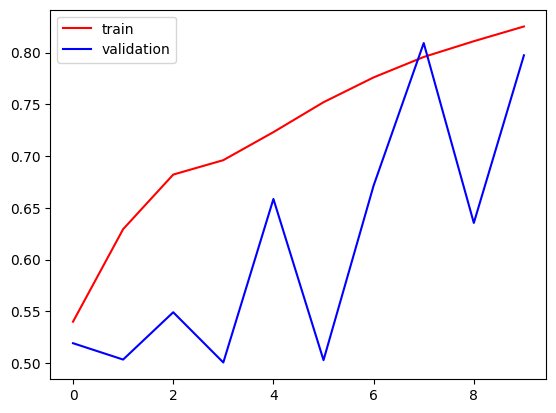

In [15]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.legend()
plt.show()

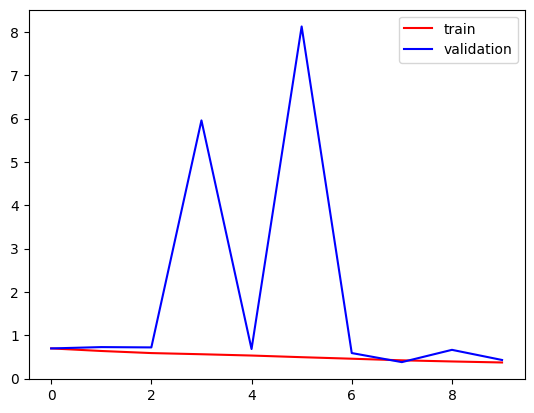

In [16]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.legend()
plt.show()


In [19]:
cnn.evaluate(test_ds)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.5017 - loss: 1.0780


[1.0779643058776855, 0.5016666650772095]

In [20]:
cnn.save('bone-fracture.keras')